# FlashRAG (Conditional Retrieval) with LangGraph

This notebook implements a detailed FlashRAG pipeline in modular blocks:
1. Judge retrieval need
2. Route query to direct answer or retrieval path
3. Retrieve, rerank, refine context
4. Generate final answer

In [2]:
# Block 1: Imports
from __future__ import annotations

from typing import TypedDict, List
import os

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langgraph.graph import StateGraph, START, END

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Block 2: State definition
class FlashRAGState(TypedDict):
    query: str
    docs: List[Document]
    vectorstore: FAISS

    need_retrieval: bool

    retrieved_docs: List[Document]
    reranked_docs: List[Document]
    refined_context: str

    answer: str

In [4]:
# Block 3: Local models
LOCAL_OLLAMA_BASE_URL = os.getenv("LOCAL_OLLAMA_BASE_URL", "http://localhost:11434")
LOCAL_LLM_MODEL = os.getenv("LOCAL_LLM_MODEL", "openvoid/Void-Gemini:latest")
LOCAL_EMBED_MODEL = os.getenv("LOCAL_EMBED_MODEL", "nomic-embed-text")

llm = ChatOllama(model=LOCAL_LLM_MODEL, base_url=LOCAL_OLLAMA_BASE_URL, temperature=0)
embedder = OllamaEmbeddings(model=LOCAL_EMBED_MODEL, base_url=LOCAL_OLLAMA_BASE_URL)

print("LLM:", LOCAL_LLM_MODEL)
print("Embeddings:", LOCAL_EMBED_MODEL)

LLM: openvoid/Void-Gemini:latest
Embeddings: nomic-embed-text


In [5]:
# Block 4: Load PDF, chunk text, and build vector index
def prepare_vectorstore(pdf_path: str):
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,
        chunk_overlap=100
    )
    chunks = splitter.split_documents(docs)

    vectorstore = FAISS.from_documents(chunks, embedder)
    return docs, vectorstore

In [6]:
# Block 5: Judge whether retrieval is needed
def judge_retrieval(state: FlashRAGState):
    response = llm.invoke(f"""
    Decide if external retrieval is needed.

    Query:
    {state['query']}

    Answer YES or NO.
    """).content.lower()

    return {"need_retrieval": "yes" in response}


# Block 6: Router
def route_query(state: FlashRAGState):
    return "retrieve" if state["need_retrieval"] else "direct"

In [7]:
# Block 7: Retriever
def retrieve_docs(state: FlashRAGState):
    retriever = state["vectorstore"].as_retriever(search_kwargs={"k": 5})
    docs = retriever.invoke(state["query"])
    return {"retrieved_docs": docs}


# Block 8: LLM reranker
def rerank_docs(state: FlashRAGState):
    scored = []

    for doc in state["retrieved_docs"]:
        score = llm.invoke(f"""
        Score relevance (0-100):

        Query: {state['query']}
        Doc: {doc.page_content}
        """).content

        try:
            score_value = float(score.strip())
        except Exception:
            score_value = 50.0

        scored.append((score_value, doc))

    scored.sort(reverse=True, key=lambda x: x[0])
    return {"reranked_docs": [d for _, d in scored[:3]]}

In [8]:
# Block 9: Context refinement/compression
def refine_context(state: FlashRAGState):
    combined = "\n\n".join([d.page_content for d in state["reranked_docs"]])

    refined = llm.invoke(f"""
    Extract only relevant information:

    {combined}
    """).content

    return {"refined_context": refined}


# Block 10: Generator with context
def generate_answer(state: FlashRAGState):
    context = state.get("refined_context", "")

    answer = llm.invoke(f"""
    Answer the question clearly.

    QUESTION:
    {state['query']}

    CONTEXT:
    {context}
    """).content

    return {"answer": answer}


# Block 11: Direct answer node
def direct_answer(state: FlashRAGState):
    answer = llm.invoke(f"""
    Answer directly:

    {state['query']}
    """).content

    return {"answer": answer}

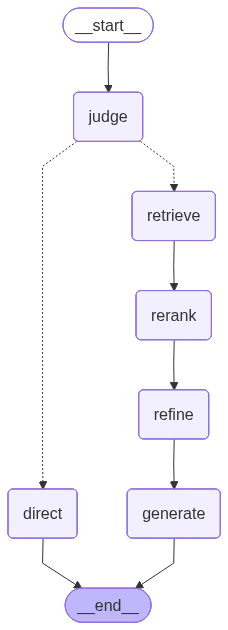

In [9]:
# Block 12: Build FlashRAG LangGraph
def build_flashrag():
    builder = StateGraph(FlashRAGState)

    builder.add_node("judge", judge_retrieval)
    builder.add_node("retrieve", retrieve_docs)
    builder.add_node("rerank", rerank_docs)
    builder.add_node("refine", refine_context)
    builder.add_node("generate", generate_answer)
    builder.add_node("direct", direct_answer)

    builder.add_edge(START, "judge")

    builder.add_conditional_edges(
        "judge",
        route_query,
        {
            "retrieve": "retrieve",
            "direct": "direct"
        }
    )

    builder.add_edge("retrieve", "rerank")
    builder.add_edge("rerank", "refine")
    builder.add_edge("refine", "generate")

    builder.add_edge("direct", END)
    builder.add_edge("generate", END)

    return builder.compile()


app = build_flashrag()
app

In [10]:
# Block 13: Main loop (notebook-friendly)
PDF_PATH = os.getenv("FLASHRAG_PDF_PATH", r"e:\LangGraph\RAGs\GraphRAG\GraphRAG.pdf")

print("Loading and indexing...")
docs, vectorstore = prepare_vectorstore(PDF_PATH)

print("FlashRAG Ready (Conditional Pipeline)")

while True:
    query = input("Ask: ").strip()

    if query.lower() == "exit":
        break

    if not query:
        print("Please enter a query.")
        continue

    result = app.invoke({
        "query": query,
        "docs": docs,
        "vectorstore": vectorstore
    })

    print("\nANSWER:\n")
    print(result["answer"])
    print("\n" + "=" * 60)

Loading and indexing...
FlashRAG Ready (Conditional Pipeline)

ANSWER:

Kathmandu


ANSWER:

Based on the provided text, here is a summary of **GraphRAG**:

GraphRAG is an advanced retrieval-augmented generation system designed to provide a global understanding of large datasets. Unlike standard RAG, it organizes information into a **hierarchical graph index**.

**Key features include:**
*   **Hierarchical Summarization:** It partitions data into "communities" and generates summaries for each. This "divide-and-conquer" approach allows the system to act as a "self-memory" for the dataset.
*   **Multi-Stage Querying:** To answer a question, the system processes information through a sequence: it looks at community summaries, generates community-specific answers, and finally aggregates them into a comprehensive global answer.
*   **Scalability:** It is built for very large datasets. It manages LLM context window limits by iteratively substituting long summaries with shorter, high-level su